<a href="https://colab.research.google.com/github/Adeline187/Build_and_Deploy-ML/blob/main/EXPT5/Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT 4B — RANDOM FOREST CLASSIFIER

AIM:
To implement a Random Forest classifier for a classification task, tune key hyperparameters, evaluate performance, and interpret feature importance.

In [2]:
# 1) Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

ALGORITHM:

1. Import libraries.
2. Load the Breast Cancer dataset.
3. Split the dataset into training and testing sets using stratification.
4. Random Forest does not require feature scaling, so raw features are used.
5. Create a Random Forest classifier.
6. Perform hyperparameter tuning using GridSearchCV.
7. Train the best Random Forest model.
8. Evaluate the model using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.
9. Plot the top 10 feature importances and ROC curve.

In [3]:
# 2) Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset Shape:", X.shape)

print("\nFirst 5 rows:")
print(X.head())

Dataset Shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

TRAIN/TEST SPLIT:

The dataset is divided into training and testing data.
80% of the data is used for training and 20% is used for testing.
Stratification is used to maintain the class distribution.

In [4]:
# 3) Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


RANDOM FOREST MODEL:

A Random Forest classifier is created.
Random Forest combines multiple decision trees to perform classification.

In [5]:
# 4) Define Random Forest Model

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

HYPERPARAMETER TUNING:

GridSearchCV is used to find the best combination of Random Forest hyperparameters.

The parameters considered are:
• Number of estimators
• Maximum depth
• Minimum samples required to split a node
• Minimum samples required at a leaf

In [6]:
# 5) Hyperparameter Grid and Tuning

param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 10],
    "min_samples_split": [2],
    "min_samples_leaf": [1]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best Parameters (CV):")
print(grid.best_params_)

best_rf = grid.best_estimator_

Best Parameters (CV):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


MODEL TRAINING AND PREDICTION:

The best Random Forest model obtained from GridSearchCV is trained on the training data and used to predict the test data.

In [7]:
# 6) Train Final Model and Predict

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:, 1]

MODEL EVALUATION:

The Random Forest model is evaluated using:
• Accuracy
• Precision
• Recall
• F1-Score
• ROC-AUC
• Confusion Matrix
• Classification Report

In [8]:
# 7) Evaluate the Model

acc = accuracy_score(y_test, y_pred)

prec = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n=== Random Forest — Test Metrics ===")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


=== Random Forest — Test Metrics ===
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655
ROC-AUC  : 0.9937

Confusion Matrix:
[[39  3]
 [ 2 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



FEATURE IMPORTANCE:

Feature importance is used to identify the features that contribute most to the Random Forest classification.
The top 10 important features are displayed using a bar graph.


Top 10 Feature Importances:
worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
mean perimeter          0.069574
mean radius             0.068676
mean concavity          0.057638
mean area               0.049172
worst concavity         0.034340
dtype: float64


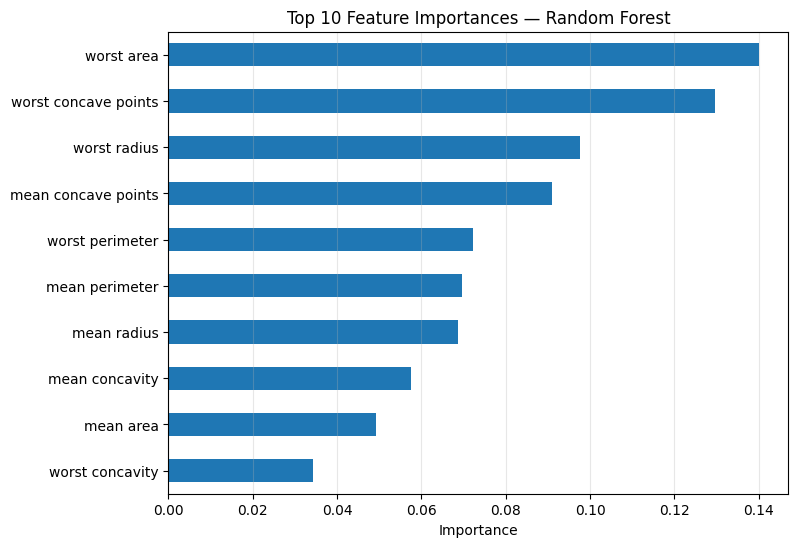

In [9]:
# 8) Feature Importance — Top 10

importances = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

top10 = importances.sort_values(
    ascending=False
).head(10)

print("\nTop 10 Feature Importances:")
print(top10)

plt.figure(figsize=(8, 6))

top10[::-1].plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title(
    "Top 10 Feature Importances — Random Forest"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

ROC CURVE:

The ROC curve is plotted to visualize the classification performance of the Random Forest model.
The Area Under the Curve (AUC) value is also displayed.

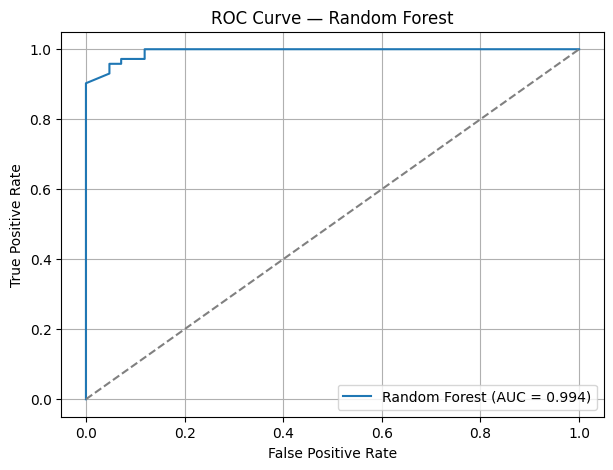

In [10]:
# 9) ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Random Forest"
)

plt.legend()
plt.grid(True)

plt.show()